# Instructions

- All code must be contained in this notebook. No separate code files.
- The code must compile and run without errors.
- Submit as `[your_name].ipynb` with a separate `[your_name]_requirements.txt` file.
- Be prepared to discuss your design decisions in the technical interview.

# Describe the environment that have been used to complete the task
- Python version: 3.11.9
- GPU used for training (if any): NVIDIA RTX 3050
- CPU used for inference timing: AMD Ryzen 5 5600H

# Imports, Functions, Global Variables, Classes
Define all shared code in the cell below.

Set `TRAIN_MODEL` variable to `True` to train the model. Currently, it is set to `False` so it will load the provided pre-trained model. 

In [133]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from nats_bench import create
from xautodl.models import get_cell_based_tiny_net
from types import SimpleNamespace
import os
import onnxruntime
import numpy as np
from onnxruntime.quantization import quantize_static, quantize_dynamic, CalibrationDataReader, QuantType
import onnx
import matplotlib.pyplot as plt
import time
from torchsummary import summary

# Set the TORCH_HOME environment variable for NATS-Bench files
os.environ['TORCH_HOME'] = "./.torch/"

# Set to True to train the model, False to skip training and directly load the pre-trained model
TRAIN_MODEL = True 

# Define model paths
MODEL_PATH = "model.pt"
ONNX_PATH = "model.onnx"
STATIC_INT8_PATH = "model_int8_static.onnx"
DYNAMIC_INT8_PATH = "model_dynamic_int8.onnx"

# Model hyperparameters and training settings
INDEX = 4881          # Best NATS-Bench architecture index for given constraints
EPOCHS = 100
BATCH_SIZE = 256
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OPTIMIZER = "SGD"  # Options: "SGD", "Adam", "AdamW"

# Same data pre-processing as NATS-Bench
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    ),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    ),
])

# Train set: 50K images, Test set: 10K images
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# NATS-Bench models return tuple where the first element is the output and the second element is a dictionary of additional information, 
# so the output is manually extracted accordingly
def inference(model, x):
    out = model(x)
    return out[0] if isinstance(out, tuple) else out

# Function to get file size in KB
def get_file_size_kb(file_path):
    size_bytes = os.path.getsize(file_path)
    size_kb = size_bytes / 1024
    return size_kb

# Function to evaluate ONNX model accuracy and inference speed
def evaluate_onnx_model(model_path, dataloader):
    # Create ONNX runtime session
    ort_sess = onnxruntime.InferenceSession(model_path)
    # Measure test accuracy and inference speed
    correct = 0
    total = 0
    inference_times = np.zeros((len(dataloader.dataset), 1))
    for i, (images, labels) in enumerate(dataloader):
        images_np = images.numpy()
        start_time = time.time()
        outputs = ort_sess.run(None, {'input': images_np})
        end_time = time.time()
        logits = outputs[0]
        preds = np.argmax(logits, axis=1)
        correct += (preds == labels.numpy()).sum()
        total += labels.size(0)
        inference_times[i] = (end_time - start_time) * 1000  # Batch inference time in milliseconds

    print(f"Test Accuracy: {100 * correct / total:.2f}%")
    print(f"Inference time: {np.mean(inference_times):.3f} ms")
    print(f"Model size: {get_file_size_kb(model_path):.2f} KB")

Files already downloaded and verified
Files already downloaded and verified


# 2.1 Design of a Compact CNN

**Requirements:**
- Model size: < 500 KB (FP32)
- Target test accuracy: ≥ 85%

If `TRAIN_MODEL` was set to `False`, this cell takes ~ 2.5 to 3.5 minutes to run.   
If `TRAIN_MODEL` was set to `True`, this cell takes ~50 minutes to run on my GPU.

[2026-02-23 19:51:02] Try to use the default NATS-Bench (size) path from fast_mode=True and path=None.
Selected architecture index: 4881
Epoch  10 | loss 0.5603 | test acc 77.57%
Epoch  20 | loss 0.4780 | test acc 71.02%
Epoch  30 | loss 0.4329 | test acc 76.82%
Epoch  40 | loss 0.3913 | test acc 81.67%
Epoch  50 | loss 0.3571 | test acc 80.92%
Epoch  60 | loss 0.3109 | test acc 83.59%
Epoch  70 | loss 0.2645 | test acc 86.51%
Epoch  80 | loss 0.2030 | test acc 86.94%
Epoch  90 | loss 0.1492 | test acc 89.14%
Epoch 100 | loss 0.1237 | test acc 89.70%
Training complete!


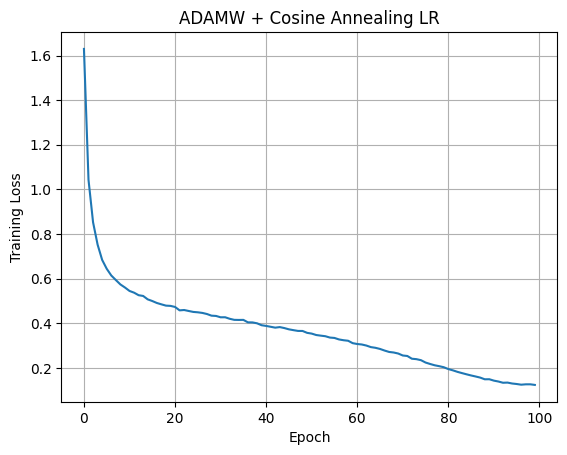

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             432
       BatchNorm2d-2           [-1, 16, 32, 32]              32
              ReLU-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 16, 32, 32]           2,304
       BatchNorm2d-5           [-1, 16, 32, 32]              32
        ReLUConvBN-6           [-1, 16, 32, 32]               0
              ReLU-7           [-1, 16, 32, 32]               0
            Conv2d-8           [-1, 16, 32, 32]           2,304
       BatchNorm2d-9           [-1, 16, 32, 32]              32
       ReLUConvBN-10           [-1, 16, 32, 32]               0
             ReLU-11           [-1, 16, 32, 32]               0
           Conv2d-12           [-1, 16, 32, 32]           2,304
      BatchNorm2d-13           [-1, 16, 32, 32]              32
       ReLUConvBN-14           [-1, 16,

In [ ]:
# Create the NATS-Bench API and get the model for the specified architecture index
api = create(None, 'sss', fast_mode=True, verbose=False)

# Set model constraints for architecture search
param_max=0.105 # This is apporimately 420 KB of parameters
hp ='90'    # Evaluate on model performance after 90 epochs of training

# Find the model index of highest accuracy that satisfies the parameter constraint
index, _ = api.find_best(dataset='cifar10', metric_on_set='test', param_max=param_max, hp=hp)
print(f"Selected architecture index: {index}")

# Create model configuration based on found architecture index
config = api.get_net_config(index, 'cifar10')
config = SimpleNamespace(**config)
model = get_cell_based_tiny_net(config).to(DEVICE)  # A Pytorch model instance of selected architecture index

if TRAIN_MODEL:
    # Training settings (loss function, optimizer, and learning rate scheduler)
    criterion = nn.CrossEntropyLoss()
    
    match OPTIMIZER:
        case "SGD":
            optimizer = optim.SGD(
            model.parameters(),
            lr=LR,
            momentum=MOMENTUM,
            weight_decay=WEIGHT_DECAY,
            nesterov=True
        )
        case "Adam":
            optimizer = optim.Adam(
            model.parameters(), 
            lr=LR, 
            weight_decay=WEIGHT_DECAY
            )
        case "AdamW":
            optimizer = optim.AdamW(
            model.parameters(), 
            lr=LR, 
            weight_decay=WEIGHT_DECAY
            )
        case _:
            raise ValueError("Choose a valid optimizer: 'SGD', 'Adam', or 'AdamW'")

    # Cosine decay schedular
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )

    loss_log = []   # Log the training loss for plotting

    # Training loop
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        batches = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = inference(model, inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            batches += 1

        scheduler.step()

        avg_loss = total_loss / batches 
        loss_log.append(avg_loss)   # log the loss

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = inference(model, inputs)
                _, pred = outputs.max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

        acc = 100 * correct / total
        if((epoch + 1) % 10 == 0):   # Print training details after every 10 epochs
            print(f"Epoch {epoch+1:3d} | loss {avg_loss:.4f} | test acc {acc:.2f}%")

        torch.save(model, MODEL_PATH)

    print("Training complete!")

    # Plot training loss
    plt.plot(loss_log)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.grid()
    plt.show()

else:
    model = torch.load("model_4881.pt")

# Display model architecture
summary(model, (3, 32, 32))

# Measure test accuracy and inference speed
model.to('cpu') # To evaluate on CPU
model.eval()
correct = 0
total = 0
inference_times = np.zeros((len(testloader.dataset), 1))
with torch.no_grad():
    for i, (inputs, labels) in enumerate(testloader):
        inputs, labels = inputs.to('cpu'), labels.to('cpu')
        start_time = time.time()
        outputs = inference(model, inputs)
        end_time = time.time()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
        inference_times[i] = (end_time - start_time) * 1000  # Batch inference time in milliseconds

acc = 100 * correct / total
 
print(f"Test accuracy: {acc:.2f}%")
print(f"Inference time: {np.mean(inference_times):.3f} ms")
print(f"Model file size: {get_file_size_kb(MODEL_PATH):.2f} KB")

**Fill-in the Results:**
- Model Size: 469 KB
- Test Accuracy: 89.7 %

**Provide brief notes (architecture choice, training decisions):**
- Archictecture design was automated using Neural Architecture Search (NAS) method provided by NATS-Bench with size constraint. 
- The obtained architecture has the following sequential structure:
    - Conv+BN
    - 5 x ReLu+Conv+BN
    - (2 x ResNet) + downsample
    - 6 x ReLU+Conv+BN
    - (2 x ResNet) + downsample
    - 6 x ReLU+Conv+BN
    - Global pooling + Classifier
- Model was trained for 100 epochs. Three optimizers were explored and best combination was SGD optimizer paired with cosine decay learning rate schedular.

# 2.2 Inference using ONNXRuntime (CPU)

Export your model to ONNX and run inference using ONNXRuntime (CPU).

This cell takes ~10 seconds to run

In [131]:
# Dummy input for CIFAR-10 image shape
dummy_input = torch.randn(1, 3, 32, 32)

model.to("cpu")  # ONNX export requires CPU model

# Export to ONNX
torch.onnx.export(model, 
                  dummy_input, 
                  ONNX_PATH, 
                  opset_version=20, # PyTorch supports upto version 20
                  input_names=["input"],
                  output_names=["output"],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}, # Flexible batch size
                  verbose=False)

print("ONNX conversion complete!")

# Measure ONNX model accuracy and inference speed
evaluate_onnx_model(ONNX_PATH, testloader)

ONNX conversion complete!
Test Accuracy: 89.69%
Inference time: 0.339 ms
Model size: 409.98 KB


**Fill-in the Results:**
- ONNX Model Size: 410 KB
- Test Accuracy (ONNX): 89.69 %
- Inference Time (FP32 Original): 0.840  ms/batch
- Inference Time (ONNX FP32): 0.339 ms/batch

**Provide brief comparison/analysis:**
- Graph optimization in ONNX compressed the model size further.
- Accuracy is same across both formats.
- ONNX model is faster due to its optimized graph. PyTorch generally creates network graph during run-time making it slower and is more suitable for GPU inference.

# 2.3 Post Training Quantization (Static)
Perform INT8 static quantization. Target: < 5% accuracy drop from FP32.

This cell takes ~15 seconds to run.

In [136]:
# A calibration reader that feeds 300 sample images to compute static scale factors
class CIFARReader(CalibrationDataReader):
    def __init__(self, dataset, input_name, num_samples=300):
        self.input_name = input_name
        self.data = []
        for i in range(num_samples):
            img, _ = dataset[i]
            self.data.append({input_name: img.unsqueeze(0).numpy()})
        self.enum = iter(self.data)

    def get_next(self):
        return next(self.enum, None)

model = onnx.load(ONNX_PATH)    # Input ONNX model
input_name = model.graph.input[0].name
dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
reader = CIFARReader(dataset, input_name)

# Run static quantization
quantize_static(
    model_input=ONNX_PATH,
    model_output=STATIC_INT8_PATH,
    calibration_data_reader=reader,
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QInt8,
    per_channel=False,
    extra_options={"EnableSubgraph": True}
)

print("Static quantization complete!")

# Measure accuracy and inference speed of the quantized model
evaluate_onnx_model(STATIC_INT8_PATH, testloader)

Files already downloaded and verified


Static quantization complete!
Test Accuracy: 89.66%
Inference time: 0.673 ms
Model size: 159.66 KB


**Fill-in the Results:**
- INT8 Model Size: 160 KB
- INT8 Test Accuracy: 89.73 %
- Accuracy Drop: 0.03 %
- Inference Time (INT8): 0.716 ms/batch

**Quantization settings used:**
- weight_type=QuantType.QInt8
- activation_type=QuantType.QInt8
- per_channel=False
- extra_options={"EnableSubgraph": True}

# **OPTIONAL - BONUS** 2.4 Post Training Quantization (Dynamic)

*(Optional)* Perform INT8 dynamic quantization.

Code cell below takes ~20 seconds to run

In [138]:
# Run dynamic quantization
quantize_dynamic(
    model_input=ONNX_PATH,
    model_output=DYNAMIC_INT8_PATH,
    weight_type=QuantType.QUInt8,    # Currently ConvInt operation is only supported for unsigned integers
    per_channel=False,
    extra_options={"EnableSubgraph": True}
)

print("Dynamic quantization complete!")

# Measure accuracy and inference speed of the quantized model
evaluate_onnx_model(DYNAMIC_INT8_PATH, testloader)

Dynamic quantization complete!
Test Accuracy: 89.98%
Inference time: 1.427 ms
Model size: 151.08 KB


**Results:**
- INT8 Model Size: 152 KB
- INT8 Test Accuracy: 89.98 %
- Accuracy Drop: 0 %
- Inference Time (INT8): 1.427 ms/batch

**Comparison with static quantization:**
- Model is 8KB smaller as activation scale factors aren't being stored.
- Accuracy is same.
- Model is almost 2x slower as weights are quantized with unsigned integer which is inefficient.

# Summary Table

| Metric | FP32 (Original) | FP32 (ONNX) | INT8 Static | INT8 Dynamic (Optional) |
|--------|-----------------|-------------|-------------|--------------|
| Size (KB) | 469 | 410 | 160 | 152 |
| Accuracy (%) | 89.7 | 89.69 | 89.73 | 89.98 |
| Inference (ms) | 0.840 | 0.339 | 0.716 | 1.427 |